In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
df = pd.read_csv("predictive_maintenance.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [10]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [6]:
df['Target'].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [7]:
df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

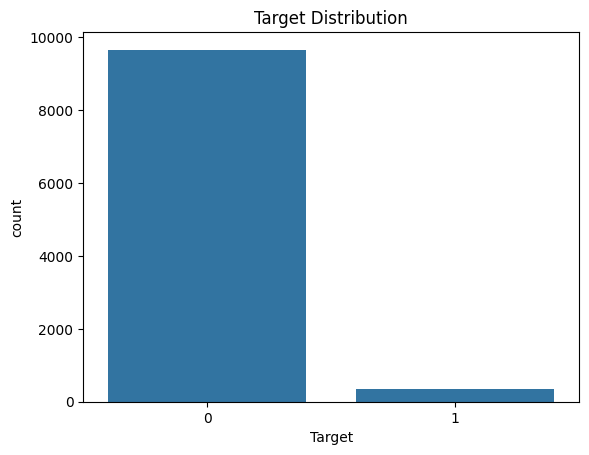

In [8]:
sns.countplot(x='Target', data=df)
plt.title("Target Distribution")
plt.show()

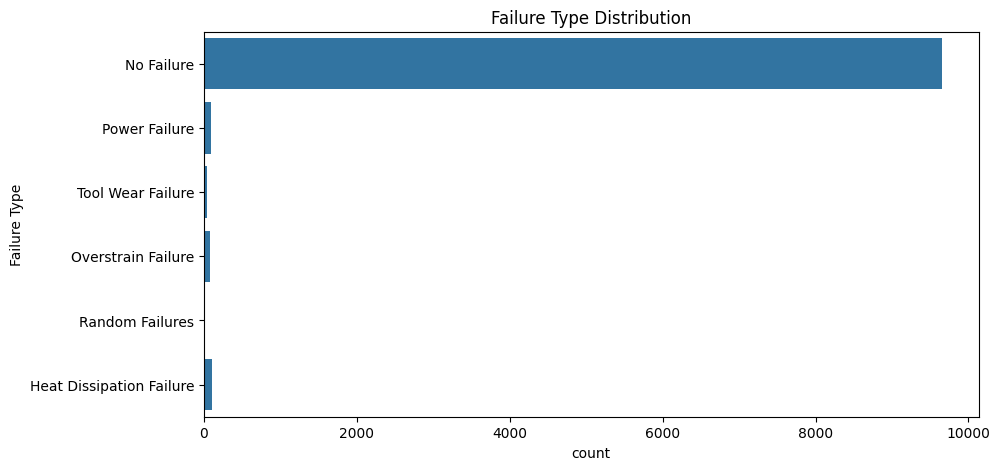

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(y='Failure Type', data=df)
plt.title("Failure Type Distribution")
plt.show()

## The dataset is highly imbalance 
Failure events account for only 3.39% of data

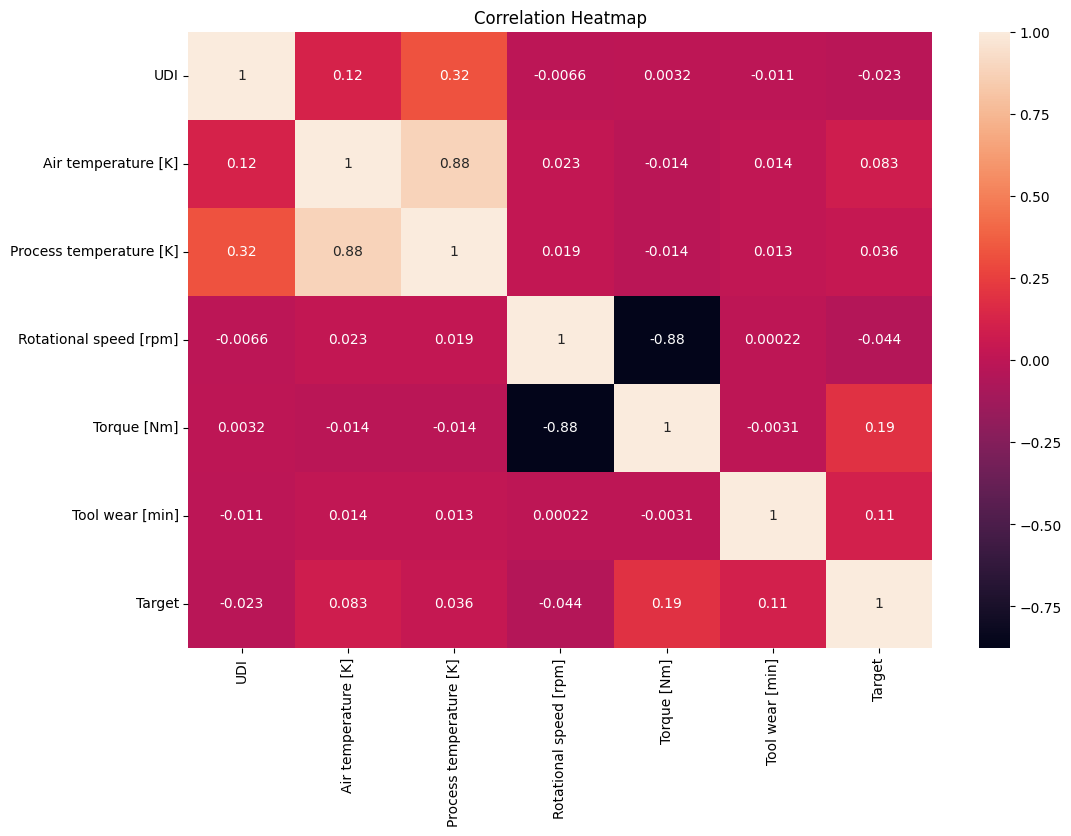

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
df = df.drop(['UDI', 'Product ID', 'Failure Type'], axis=1)

# Dropping 'Failure Type' to prevent data leakage, since it directly indicates the specific failure class.
# The model should predict failure from sensor readings, not from already-known failure labels.

In [15]:
df = pd.get_dummies(df, columns=['Type'], drop_first=True) 

In [16]:
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [17]:
df[['Type_L', 'Type_M']] = df[['Type_L', 'Type_M']].astype(int)

In [18]:
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


## Train test split:

In [19]:
X = df.drop('Target', axis=1)
y = df['Target']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Random Forest :

In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = rf.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.981
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.94      0.47      0.63        68

    accuracy                           0.98      2000
   macro avg       0.96      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000



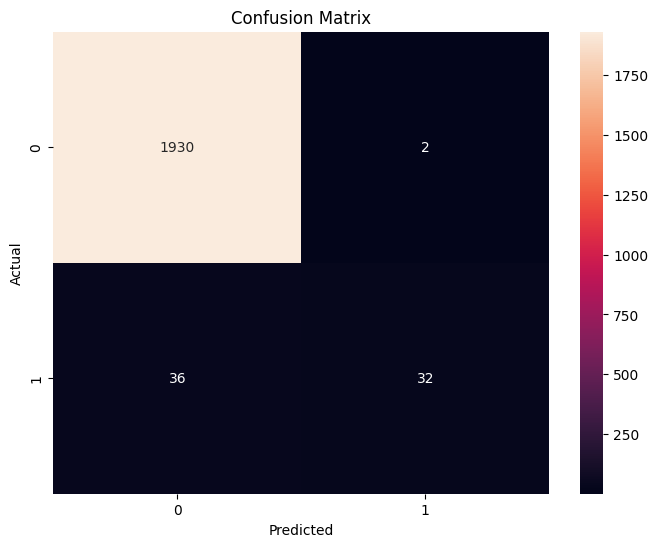

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
baseline_pred = y_pred

## Improving recall :

In [25]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [27]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred_smote = rf.predict(X_test)
print(classification_report(y_test, y_pred_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1932
           1       0.41      0.71      0.52        68

    accuracy                           0.96      2000
   macro avg       0.70      0.84      0.75      2000
weighted avg       0.97      0.96      0.96      2000

Accuracy: 0.956


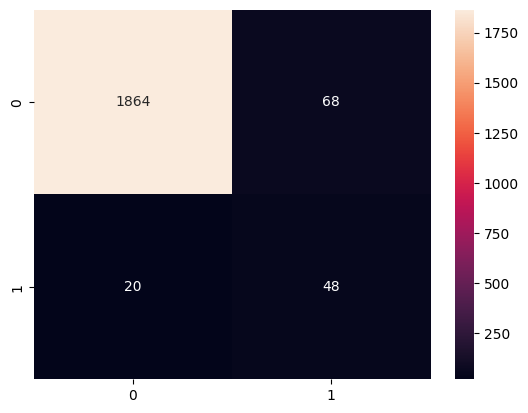

In [30]:
cm = confusion_matrix(y_test, y_pred_smote)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## Increasing number of decision trees in the random forest:

In [31]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train_smote, y_train_smote)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred_tuned = rf_tuned.predict(X_test)

print(classification_report(y_test, y_pred_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.35      0.71      0.46        68

    accuracy                           0.94      2000
   macro avg       0.67      0.83      0.72      2000
weighted avg       0.97      0.94      0.95      2000

Accuracy: 0.9445


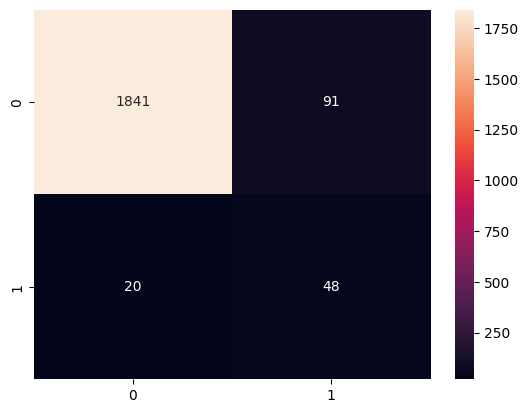

In [33]:
cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [36]:
comparison = pd.DataFrame({
    'Model': [
        'Baseline Random Forest',
        'SMOTE Random Forest',
        'Tuned SMOTE Random Forest'
    ],
    'Accuracy': [
        0.9810,
        0.9560,
        0.9445
    ],
    'Failure Precision': [
        0.94,
        0.41,
        0.35
    ],
    'Failure Recall': [
        0.47,
        0.71,
        0.71
    ],
    'Failure F1-Score': [
        0.63,
        0.52,
        0.46
    ]
})

comparison

comparison.style.highlight_max(axis=0)

,Model,Accuracy,Failure Precision,Failure Recall,Failure F1-Score
0,Baseline Random Forest,0.981000,0.940000,0.470000,0.630000
1,SMOTE Random Forest,0.956000,0.410000,0.710000,0.520000
2,Tuned SMOTE Random Forest,0.944500,0.350000,0.710000,0.460000


In [37]:
import pickle

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [38]:
import os
os.listdir()

['.ipynb_checkpoints',
 'EDA.ipynb',
 'predictive_maintenance.csv',
 'rf_model.pkl']